# Chapter 15: Quantum Amplitude Estimation

Quantum Amplitude Estimation (QAE) estimates a probability $p=\sin^2\theta$ -- the chance of measuring a "good" outcome from a state $|\psi\rangle=\sin\theta\,|s\rangle+\cos\theta\,|s^\perp\rangle$ -- with a **quadratic speedup** over classical Monte Carlo: $O(1/\varepsilon)$ oracle queries instead of $O(1/\varepsilon^2)$ shots. The engine is the Grover operator of Chapter 12, which rotates $|\psi\rangle$ by $2\theta$; a measurement after $Q^k U_\psi$ yields the good outcome with probability $\sin^2\!\big((2k+1)\theta\big)$, so larger $k$ sharpens the sensitivity to $\theta$.

This notebook works through **Iterative QAE (IQAE)** (Book §15.1–15.3): a hand-traced run that shrinks the bracket on $\theta$ round by round, Qiskit's `IterativeAmplitudeEstimation`, and two applications -- estimating a geometric **area fraction** (§15.4) and extracting the **LCU observable** $|f^\top A x|$ of Chapter 14 (§15.5). IQAE reaches $O(1/\varepsilon)$ complexity with a single ancilla, no QFT and no phase-estimation register, and returns rigorous confidence intervals.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

In [5]:
# Setup and imports
import matplotlib.pyplot as plt

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler 
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from Chapter04_EngineeringProblems_functions import (truss2x2,truss2x3,truss3x3)

## IQAE illustrated: three rounds by hand  *(Book §15.1, Example 15.1)*

To expose the mechanism, we trace IQAE with a hidden truth $\theta=0.5$ (so $p=\sin^2 0.5=0.2298$), $N=100$ shots per round and the fixed counts $23, 36, 51$. Each round:
1. **Schedule** the largest Grover power $k$ that keeps the magnified bracket $(2k+1)[\theta_\ell,\theta_u]$ inside a single monotone arc of $\sin^2$ (no aliasing).
2. **Sample** $Q^k U_\psi$, form $\hat p$ and its 95% interval.
3. **Invert** through $\sin^2$ and divide by $(2k+1)$ to get an interval in $\theta$.
4. **Intersect** with the previous bracket.

The schedule $k=0,2,16$ shrinks the width on $p$ from $0.165$ to $0.005$ in three rounds -- 300 shots total, where plain Monte Carlo would need $\sim10^5$.

In [ ]:

from Chapter15_QAE_functions import (iqae, print_table, plot_rounds_wedge, plot_rounds_linear)

THETA_TRUE = 0.5                       # hidden truth; p = sin^2(0.5) = 0.2298

# ---- reproduce the worked example in the text -------------------
print("Worked example (fixed counts 23, 36, 51):")
book = iqae(THETA_TRUE, N=100, max_rounds=3, fixed_counts=[23, 36, 51])
print_table(book)
plot_rounds_wedge(book, theta_true=0.5);

## Reader run: live random sampling  *(Book §15.1)*

The same routine with `fixed_counts=None` draws fresh random samples each round. Here we hide $\theta=0.3$ and run six rounds; the wedge containing $\theta$ tightens as the Grover power climbs, illustrating the $\varepsilon\propto1/N$ scaling that gives IQAE its quadratic edge.

In [ ]:
# ---- reader can run any number of rounds with real sampling -----
print("\nReader run (random sampling, 6 rounds, seed=1):")
theta_true = 0.3
demo = iqae(theta_true, N=100, max_rounds=6, seed=1, fixed_counts=None)
plot_rounds_linear(demo, theta_true=theta_true);

## IQAE in Qiskit on a known circuit  *(Book §15.3, Example 15.2, Listing 15.1)*

We validate against a circuit whose answer we know analytically: $U_\psi=R_y(2\theta)$ applied to $|0\rangle$ gives $\cos\theta\,|0\rangle+\sin\theta\,|1\rangle$, so with good state $|1\rangle$ the probability is $p=\sin^2\theta$. Taking $\theta=\pi/6$ fixes $p=0.25$. `IterativeAmplitudeEstimation` returns a point estimate, a 95% confidence interval, the oracle-query count and the adaptive $k$ schedule. Qiskit always defines the good subspace as $|1\rangle$ on the objective qubits.

In [ ]:
theta   = np.pi / 6
p = np.sin(theta)**2   # 0.25

epsilon_target = 0.01
# State preparation: U_psi = R_y(2 theta)
U_psi = QuantumCircuit(1)
U_psi.ry(2*theta, 0)

# Good state = |1> on qubit 0
problem = EstimationProblem(state_preparation=U_psi, objective_qubits=[0])

# Target precision for 95% confidence
iqae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target,alpha=0.05,sampler=StatevectorSampler())
result = iqae.estimate(problem)
CI = result.confidence_interval
print(f"True p:            {p:.7f}")
print(f"Epsilon target:    {epsilon_target:.7f}")
print(f"IQAE estimate:     {result.estimation:.7f}")
print(f"95% CI:            [{CI[0]:.7f}, {CI[1]:.7f}]")
print(f"Oracle queries:    {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")

## Application: area-fraction estimation  *(Book §15.4)*

We now estimate a geometric **area fraction**: on a $2^m\times2^m$ grid, the fraction of cells satisfying a Boolean predicate $g(i,j)$. Placing both coordinate registers in a uniform superposition and flipping a flag qubit exactly on the cells inside the region makes $\Pr[\text{flag}=1]=p$ the area fraction -- precisely the good/bad split IQAE estimates.

## The microstructure: a centered square hole  *(Book §15.4, Figure 15.4)*

The target region is a centered, axis-aligned square hole of side $N/2$, occupying exactly a $25\%$ area (volume) fraction. We first visualise it on a $2^5\times2^5$ grid.

In [ ]:
from Chapter04_EngineeringProblems_functions import MicrostructureGenerator
m = 5
micro = MicrostructureGenerator(2**m, 2**m, inclusion_fraction=0.25, micro_type='square')
micro.plot()

## Oracle for the square hole  *(Book §15.4, Listing 15.2)*

The geometry is chosen so the membership test factorizes: a centered hole spans $x\in[N/4,3N/4)$, which holds exactly when the top two bits of $x$ differ, $x_{m-1}\oplus x_{m-2}=1$ (and likewise for $y$). So $g(i,j)=(x_{m-1}\oplus x_{m-2})\wedge(y_{m-1}\oplus y_{m-2})$ -- the oracle touches only four qubits and stays $\sim30$ gates **regardless of $m$**. It computes each coordinate's parity onto an ancilla with two `cx` gates, combines them onto the flag with a Toffoli, then uncomputes the ancillas.

Centered square hole in 2^3 x 2^3 grid (area fraction 1/4):
--- Circuit Analysis ---
Qubits: 9
Single-qubit gates: 14
CX/ECR gates: 14
Total gates: 28
Depth: 15
Objective qubits: [0]


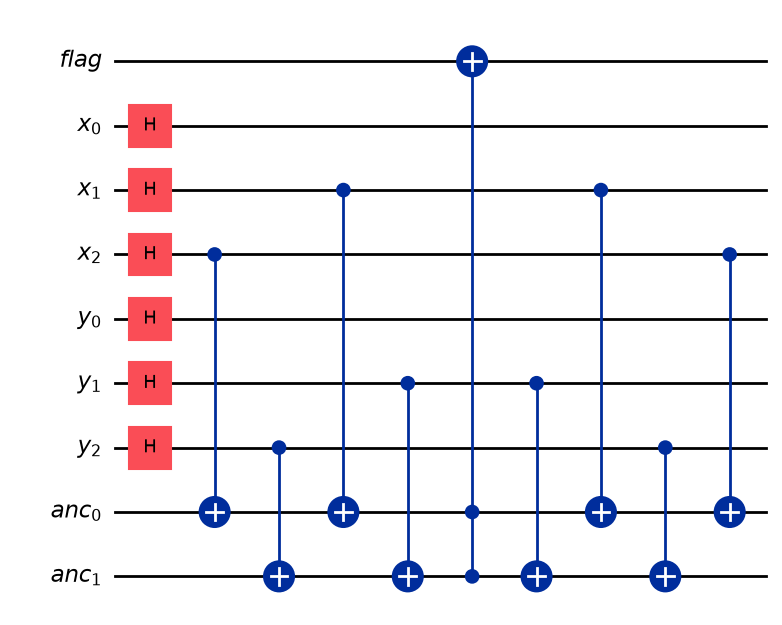

In [6]:
from Chapter08_QuantumGates_functions import estimateCircuitGates
from Chapter15_QAE_functions import square_hole_U_psi

m = 3
print(f"Centered square hole in 2^{m} x 2^{m} grid (area fraction 1/4):")
U_psi, objective = square_hole_U_psi(m)
estimateCircuitGates(U_psi);
print(f"Objective qubits: {objective}")
display(U_psi.draw('mpl', fold=10))

### Estimating the area fraction with IQAE  *(Book §15.4, Listing 15.3)*

We hand $U_\psi$ (uniform prep + oracle) to IQAE with target $\varepsilon=0.01$ and $\alpha=0.05$; the estimate brackets the true $0.25$. Refining the grid costs more qubits, but **neither more oracle gates nor more IQAE rounds** -- both the oracle gate count ($\sim30$) and the query count ($\sim6000$) stay flat in $m$.

In [7]:

epsilon_target = 0.01
problem = EstimationProblem(state_preparation=U_psi, objective_qubits=objective)
iqae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target, alpha=0.05,
                                    sampler=StatevectorSampler())
res = iqae.estimate(problem)
lo, hi = res.confidence_interval
print(f"True area fraction:  0.2500")
print(f"Epsilon target:     {epsilon_target:.6f}")
print(f"IQAE estimate:       {res.estimation:.4f}")
print(f"95% CI:              [{float(lo):.4f}, {float(hi):.4f}]")
print(f"Oracle queries:      {res.num_oracle_queries}")
print(f"k schedule:         {res.powers}")

True area fraction:  0.2500
Epsilon target:     0.010000
IQAE estimate:       0.2497
95% CI:              [0.2475, 0.2519]
Oracle queries:      8192
k schedule:         [0, 0, 8]


### Application: LCU observable estimation  *(Book §15.5, Example 15.4, Listing 15.4)*

Finally we apply IQAE to the problem that motivated the chapter: estimating the observable $|f^\top A x|$ from the LCU circuit of Chapter 14. After the LCU preparation and the inverse state-prep $U_f^\dagger$, the good state is all-zeros and the good-outcome probability is $p=|f^\top A x|^2/\lVert Ax\rVert^2$. We revisit the $4\times4$ system of Example 14.7 (classical answer $0.5811$); IQAE recovers it inside a tight confidence interval using far fewer queries than Monte Carlo would need.

In [ ]:
from Chapter15_QAE_functions import build_observable_circuit
# --- Problem definition ---
f = np.array([1., 0., 0.5, 0.2])
f = f / np.linalg.norm(f)
A_mat = np.array([[ 1.,  0.,  0., -0.5],
                  [ 0.,  1.,  0.,  0. ],
                  [ 0.,  0.,  1.,  0. ],
                  [-0.5, 0.,  0.,  1. ]])
x_vec     = np.array([0.6, 0.8, 0., 0.])
classical = np.abs(f @ A_mat @ x_vec)

# --- Build circuit ---
A_obs, metadata = build_observable_circuit(A_mat, x_vec, f)
alpha_lcu  = metadata['alpha']
p_succ     = metadata['p_success']
good_qubits = metadata['good_qubits']

# --- Statevector diagnostics ---
num_anc = metadata['num_ancilla']
num_sys = metadata['num_system']
sv = Statevector(A_obs)
probs = sv.probabilities_dict()


# --- Run IQAE ---
problem = EstimationProblem(state_preparation=A_obs, objective_qubits=good_qubits)
iqae    = IterativeAmplitudeEstimation(epsilon_target=0.01, alpha=0.05,
                                       sampler=StatevectorSampler())
result  = iqae.estimate(problem)

a_hat, (a_lo, a_hi) = result.estimation, result.confidence_interval

# --- Recovery formula ---
obs_hat = np.sqrt(a_hat) * alpha_lcu * np.sqrt(p_succ)
obs_lo  = np.sqrt(a_lo)  * alpha_lcu * np.sqrt(p_succ)
obs_hi  = np.sqrt(a_hi)  * alpha_lcu * np.sqrt(p_succ)

print("=== Results ===")
print(f"Classical:           {classical:.4f}")
print(f"IQAE estimate:       {obs_hat:.4f}")
print(f"95% CI:              [{obs_lo:.4f}, {obs_hi:.4f}]")
print(f"Oracle queries:      {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")
